## Posthoc binning: errorbar consistency check (noise-bias-subtracted)

Single-field bandpower estimator using **posthoc binning only**: we build the
per-$\ell$ Fisher matrix $F_\ell$ and per-$\ell$ estimator $\hat{y}_\ell$,
then bin afterwards via

$$\hat{c}_b = (\mathcal{P} F_\ell \mathcal{S})^{-1}\, \mathcal{P}\, \hat{y}_\ell^{\rm sub},
\qquad \hat y_\ell^{\rm sub} = \hat y_\ell - b_\ell,\quad
b_\ell = \tfrac12\,\mathrm{Tr}(C^{-1}P_\ell C^{-1}\mathbb{N}).$$

This is the paper's Eq. 9 form with the noise bias explicitly subtracted
(`qmlfast.get_y` only returns the $\tfrac12 x^T E_\ell x$ term, so we subtract
the deterministic $\tfrac12\mathrm{Tr}(E_\ell\mathbb{N})$ piece manually).

**Why this fixes both means and errorbars:**

- Fiducial keeps the white pixel-noise term $\mathbb{N}=N_a/\omega_{\rm pix}\cdot I$
  for conditioning.
- Sims draw band-limited signal via `synalm(S_aa)` and add pixel-space white noise,
  so $C_{\rm true}=C_{\rm fid}$ *exactly* $\Rightarrow \mathrm{Cov}(\hat y)=F$
  $\Rightarrow \mathrm{Cov}(\hat c_b) = F_b^{-1}$.
- The signal $\mathbb{S}_{\rm true}=\sum_\ell S_{aa}(\ell)P_\ell$ *is* in the span
  of $\{P_\ell\}$, so after noise subtraction
  $\langle\hat y_\ell^{\rm sub}\rangle = F_{\ell\ell'}\,S_{aa}(\ell')$
  and the Fisher-weighted truth for the bins is
  $F_b^{-1}\,S^T F\,S_{aa}$.

The bias subtraction is a deterministic shift (no per-sim cost), so
$\mathrm{Cov}(\hat y^{\rm sub}) = \mathrm{Cov}(\hat y) = F$ — errorbars unchanged.

In [1]:
import sys
sys.path.append('./')
import numpy as np
import healpy as hp
import matplotlib.pyplot as plt
import opt_einsum as oe
from tqdm import tqdm
import fbpca

from utilities import *
from qmlfast import *


### Setup: 1 field

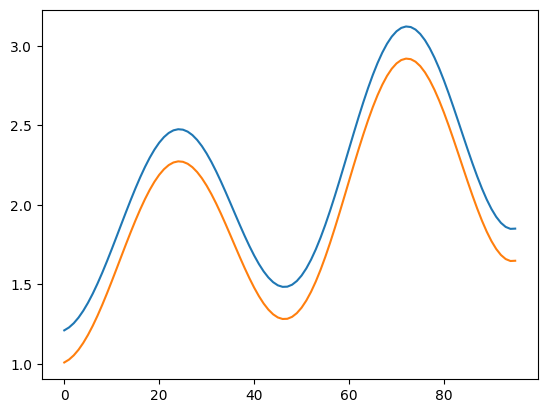

In [4]:
nside = 32
lmax = 3 * nside - 1   # 47
n_ell = 3 * nside      # 48 modes: ell = 0..47
ell = np.arange(lmax + 1, dtype=float)

S_aa = np.exp((ell+1)/n_ell/2) * (1 + np.sin((ell+1)/n_ell*np.pi*2)**2)
#S_aa = 1/(ell+1)
N_a = 1./5*S_aa[0]
C_aa = S_aa + N_a

Nf = 1
plt.plot(ell, C_aa)
plt.plot(ell, S_aa)

### Mask: growing patch

Unmasked pixels: 961
Sky fraction: 0.07820638020833333


/home/ykvasiuk/miniconda3/envs/pyccl/lib/python3.11/site-packages/healpy/pixelfunc.py:1507: RuntimeWarning: invalid value encountered in _get_neigbors_ring
  r = pixlib._get_neighbors_ring(nside, theta)


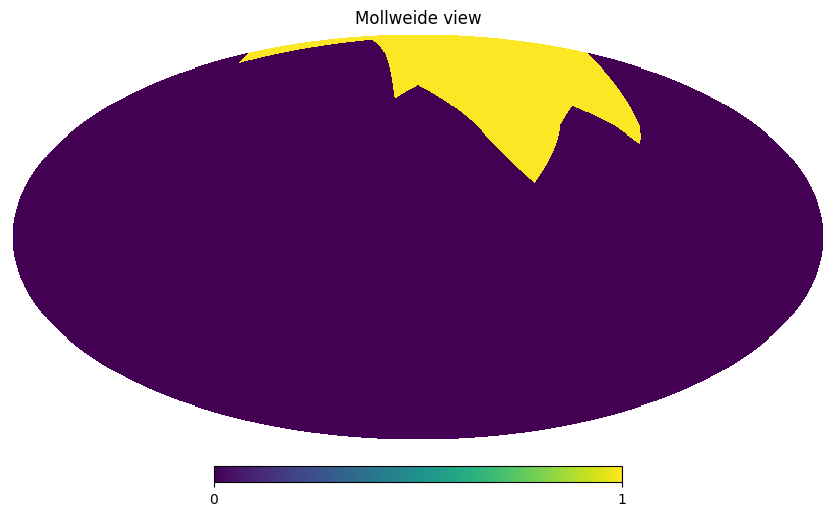

In [5]:
def gen_mask_patch(nside, seed, niter):
    npix = hp.nside2npix(nside)
    idx_bound = seed
    mask = np.zeros(npix)
    mask[seed] = 1
    masks = np.zeros((niter, npix))
    for i in range(niter):
        mask_idx = np.arange(npix)[mask != 0]
        idx = np.unique(hp.get_all_neighbours(nside, idx_bound).flatten())
        mask[idx] = 1
        masks[i] = mask
        idx_bound = np.unique(idx[~np.isin(idx, mask_idx)])
    return masks

masks = gen_mask_patch(nside, 600, 30)
mask = masks[14]
hp.mollview(mask)

theta, phi = theta_phi(nside)
theta = theta[mask == 1]
phi = phi[mask == 1]
Np = int(mask.sum())
omega_pix = 4 * np.pi / hp.nside2npix(nside)
print(f'Unmasked pixels: {Np}')
print(f'Sky fraction: {mask.mean()}')

### Pixel covariance

In [6]:
Pl_ij = get_Pl_ij(theta, phi, nside, lmax=lmax)

def get_pix_cov_block(cl, Pl_ij, lmin, lmax):
    return oe.contract('ijk,i->jk', Pl_ij[lmin:lmax], cl[lmin:lmax])

omega_pix = 4 * np.pi / hp.nside2npix(nside)

# Fiducial = band-limited signal + white pixel-space noise. The white noise
# term regularizes the matrix (gives it full rank). We'll match this in the
# sims by adding pixel-space noise there too, and subtract the resulting
# noise bias analytically from y_ell.
N_pix = (N_a / omega_pix) * np.eye(Np)      # pixel-space noise covariance
large_cov = get_pix_cov_block(S_aa, Pl_ij, 0, lmax + 1) + N_pix

print(f'cond(C_fid) = {np.linalg.cond(large_cov):.2e}')
Cinv = np.linalg.inv(large_cov)
C_map = np.ones((Nf, Nf))

cond(C_fid) = 2.45e+01


### Binning matrix: equal-width bins

In [7]:
bin_edges = []
l = 0
delta_ell = 4
while l < n_ell:
    bin_edges.append((l, min(l + delta_ell, n_ell)))
    l += delta_ell

n_bins = len(bin_edges)
P = np.zeros((n_bins, n_ell))
for b, (l_lo, l_hi) in enumerate(bin_edges):
    width = l_hi - l_lo
    P[b, l_lo:l_hi] = 1.0 / width

# S = P^+  (right pseudo-inverse, since P P^T is diagonal/invertible)
S_unbin = P.T @ np.linalg.inv(P @ P.T)
ell_eff = np.array([(l_lo + l_hi - 1) / 2 for l_lo, l_hi in bin_edges])

print(f'Number of bins: {n_bins}')
for b, (l_lo, l_hi) in enumerate(bin_edges):
    print(f'  bin {b:2d}: ell = {l_lo}..{l_hi-1} (width {l_hi-l_lo})')

Number of bins: 24
  bin  0: ell = 0..3 (width 4)
  bin  1: ell = 4..7 (width 4)
  bin  2: ell = 8..11 (width 4)
  bin  3: ell = 12..15 (width 4)
  bin  4: ell = 16..19 (width 4)
  bin  5: ell = 20..23 (width 4)
  bin  6: ell = 24..27 (width 4)
  bin  7: ell = 28..31 (width 4)
  bin  8: ell = 32..35 (width 4)
  bin  9: ell = 36..39 (width 4)
  bin 10: ell = 40..43 (width 4)
  bin 11: ell = 44..47 (width 4)
  bin 12: ell = 48..51 (width 4)
  bin 13: ell = 52..55 (width 4)
  bin 14: ell = 56..59 (width 4)
  bin 15: ell = 60..63 (width 4)
  bin 16: ell = 64..67 (width 4)
  bin 17: ell = 68..71 (width 4)
  bin 18: ell = 72..75 (width 4)
  bin 19: ell = 76..79 (width 4)
  bin 20: ell = 80..83 (width 4)
  bin 21: ell = 84..87 (width 4)
  bin 22: ell = 88..91 (width 4)
  bin 23: ell = 92..95 (width 4)


### Per-$\ell$ Fisher matrix

This is the only Fisher we build. The binned Fisher $F_b = S^T F_\ell S$ is
constructed analytically, no binned basis required.

In [8]:
Y_r_all = sph_harm_y_real_all(n_ell, theta, phi)
n_pairs = Nf * (Nf + 1) // 2  # 1 for Nf=1

F_idx_ell = np.array([(i, j, l) for l in range(n_ell)
                       for i in range(Nf) for j in range(i, Nf)])

#V_packed_ell, off_ell, rk_ell = pack_sph_harm(Y_r_all)
#F_ell = getF_packed(V_packed_ell, off_ell, rk_ell, Cinv, F_idx_ell, Nf, Np, C_map)
F_ell = getF(Y_r_all, Cinv, F_idx_ell, Nf, Np, C_map)
print(f'F_ell shape: {F_ell.shape}')
print(f'F_ell rank:  {np.linalg.matrix_rank(F_ell)}')

VCinvV: 100%|█████████████████████████████████████| 1/1 [00:00<00:00,  1.23it/s]


F_ell shape: (96, 96)
F_ell rank:  53


### Analytic binned Fisher: $F_b = \mathcal{S}^T F_\ell \mathcal{S}$

In [9]:
block_P = np.kron(P, np.eye(n_pairs))
block_S = np.kron(S_unbin, np.eye(n_pairs))

F_b = block_S.T @ F_ell @ block_S
inv_Fb = np.linalg.inv(F_b)

# Posthoc map M : y_ell -> c_b. Note (PFS)^{-1} P = (S^T F S)^{-1} S^T
# because S = P^+, so the two posthoc forms are identical.
PFS = block_P @ F_ell @ block_S
M_posthoc = np.linalg.inv(PFS) @ block_P

# Sanity: the two posthoc maps must agree to machine precision
M_alt = inv_Fb @ block_S.T
print(f'(PFS)^-1 P  vs  (S^T F S)^-1 S^T : '
      f'rel_err = {np.max(np.abs(M_posthoc - M_alt)) / np.max(np.abs(M_posthoc)):.2e}')
print(f'F_b shape: {F_b.shape}, rank: {np.linalg.matrix_rank(F_b)}')

(PFS)^-1 P  vs  (S^T F S)^-1 S^T : rel_err = 0.00e+00
F_b shape: (24, 24), rank: 24


### Build binned basis via eigendecomposition (for direct binned estimator)

Construct $P_b = \sum_\ell \mathcal{S}_{\ell b}\,P_\ell$ in pixel space,
eigendecompose to get $V_b$ s.t. $V_b V_b^T = P_b$, then compute $F_b^{\rm direct}$
from the binned basis. Should match $\mathcal{S}^T F_\ell \mathcal{S}$ exactly.

In [11]:
import fbpca
Pb_ij = np.einsum('ij,jmn->imn', S_unbin.T, Pl_ij[:n_ell])

V_list = []
for b, (l_lo, l_hi) in enumerate(bin_edges):
    max_rank = min(sum(2*l+1 for l in range(l_lo, l_hi)), Pb_ij.shape[1])
    evals, evecs = fbpca.eigens(Pb_ij[b], k=max_rank)
    order = np.argsort(np.abs(evals))[::-1]
    evals = evals[order[:max_rank]]
    evecs = evecs[:, order[:max_rank]]
    yb = evecs * np.sqrt(np.abs(evals)).reshape(1, -1)
    V_list.append(yb.T)
    print(f'  bin {b:2d} (ell {l_lo:2d}-{l_hi-1:2d}): rank = {V_list[-1].shape[0]}')

V_packed_b, offsets_b, ranks_b = pack_basis(V_list)

F_idx_b = np.array([(i, j, b) for b in range(n_bins)
                     for i in range(Nf) for j in range(i, Nf)])

F_b_direct = getF_packed(V_packed_b, offsets_b, ranks_b, Cinv, F_idx_b, Nf, Np, C_map)
inv_Fb_direct = np.linalg.inv(F_b_direct)

print(f'\nF_b (direct) vs S^T F_ell S:  rel_err = '
      f'{np.max(np.abs(F_b_direct - F_b)) / np.max(np.abs(F_b)):.2e}')

# Noise bias for the binned basis: b_b = S^T @ noise_bias_ell
# (because P_b = sum_ell S_lb P_ell, so tr(E_b N) = sum_ell S_lb tr(E_ell N))
noise_bias_b = S_unbin.T @ noise_bias

  bin  0 (ell  0- 3): rank = 16
  bin  1 (ell  4- 7): rank = 48
  bin  2 (ell  8-11): rank = 80
  bin  3 (ell 12-15): rank = 112
  bin  4 (ell 16-19): rank = 144
  bin  5 (ell 20-23): rank = 176
  bin  6 (ell 24-27): rank = 208
  bin  7 (ell 28-31): rank = 240
  bin  8 (ell 32-35): rank = 272
  bin  9 (ell 36-39): rank = 304
  bin 10 (ell 40-43): rank = 336
  bin 11 (ell 44-47): rank = 368
  bin 12 (ell 48-51): rank = 400
  bin 13 (ell 52-55): rank = 432
  bin 14 (ell 56-59): rank = 464
  bin 15 (ell 60-63): rank = 496
  bin 16 (ell 64-67): rank = 528
  bin 17 (ell 68-71): rank = 560
  bin 18 (ell 72-75): rank = 592
  bin 19 (ell 76-79): rank = 624
  bin 20 (ell 80-83): rank = 656
  bin 21 (ell 84-87): rank = 688
  bin 22 (ell 88-91): rank = 720
  bin 23 (ell 92-95): rank = 752


VCinvV: 100%|█████████████████████████████████████| 1/1 [00:00<00:00,  4.70it/s]


F_b (direct) vs S^T F_ell S:  rel_err = 1.93e-13


### Noise bias and simulations

Compute the per-$\ell$ noise bias $b_\ell = \tfrac12\mathrm{Tr}(C^{-1}P_\ell C^{-1}\mathbb{N})$
once, then for every sim draw band-limited signal + pixel-space white noise,
call `get_y`, and subtract $b_\ell$.

In [12]:
# Noise bias vector: b_l = (1/2) tr(C^-1 P_l C^-1 N)
Cinv_N_Cinv = Cinv @ N_pix @ Cinv
noise_bias = 0.5 * np.einsum('ij,lji->l', Cinv_N_Cinv, Pl_ij[:n_ell])

n_sims = 1000
rng = np.random.default_rng(42)

ys_ell = []      # per-ell y (noise-subtracted)
ys_bin = []      # direct binned y (noise-subtracted)
for i in tqdm(range(n_sims)):
    alm_s = hp.synalm(S_aa, lmax=lmax)
    sig = hp.alm2map(alm_s, nside)[mask == 1]
    noise = rng.normal(0, np.sqrt(N_a / omega_pix), Np)
    x = np.array([sig + noise])

    # Per-ell estimator (posthoc route)
    y_ell = get_y(x, Y_r_all, Cinv, F_idx_ell, Nf, Np)
    ys_ell.append(y_ell - noise_bias)

    # Direct binned estimator
    y_bin = get_y_packed(x, V_packed_b, offsets_b, ranks_b,
                         Cinv, F_idx_b, Nf, Np)
    ys_bin.append(y_bin - noise_bias_b)

ys_ell = np.array(ys_ell)
ys_bin = np.array(ys_bin)
print(f'ys_ell shape: {ys_ell.shape}  ys_bin shape: {ys_bin.shape}')


100%|███████████████████████████████████████| 1000/1000 [02:13<00:00,  7.49it/s]

ys_ell shape: (1000, 96)  ys_bin shape: (1000, 24)


### Posthoc binning of the simulated $\hat{y}_\ell$

In [13]:
# c_hat_b = (PFS)^{-1} P y_ell^sub, applied to every sim
c_hat = ys_ell @ M_posthoc.T
c_mean = c_hat.mean(axis=0)
c_cov_emp = np.cov(c_hat, rowvar=False, ddof=1)

# After noise-bias subtraction, <y_ell> = F @ S_aa, so the Fisher-weighted
# truth uses S_aa (signal only), NOT C_aa = S_aa + N_a.
S_true_b = inv_Fb @ (block_S.T @ F_ell @ S_aa[:n_ell])
S_naive_b = P @ S_aa[:n_ell]

print('Bin centers and signal bandpowers (noise-subtracted estimator):')
print(f'{"bin":>3} {"l_range":>10} {"l_eff":>6} {"Fisher-wt":>12} {"naive P@S":>12} {"ratio":>8}')
for b in range(n_bins):
    lo, hi = bin_edges[b]
    r = S_true_b[b] / S_naive_b[b]
    print(f'{b:>3d} {f"{lo}-{hi-1}":>10} {ell_eff[b]:>6.1f} '
          f'{S_true_b[b]:>12.6f} {S_naive_b[b]:>12.6f} {r:>8.4f}')

# alias for the downstream plotting / bias-check cells
C_true_b = S_true_b

Bin centers and signal bandpowers (noise-subtracted estimator):
bin    l_range  l_eff    Fisher-wt    naive P@S    ratio
  0        0-3    1.5     1.037228     1.045266   0.9923
  1        4-7    5.5     1.205823     1.214617   0.9928
  2       8-11    9.5     1.479967     1.482852   0.9981
  3      12-15   13.5     1.792314     1.789608   1.0015
  4      16-19   17.5     2.069801     2.061590   1.0040
  5      20-23   21.5     2.243673     2.232102   1.0052
  6      24-27   25.5     2.271523     2.259615   1.0053
  7      28-31   29.5     2.149193     2.140219   1.0042
  8      32-35   33.5     1.913744     1.910300   1.0018
  9      36-39   37.5     1.635004     1.638288   0.9980
 10      40-43   41.5     1.397855     1.407272   0.9933
 11      44-47   45.5     1.279617     1.292861   0.9898
 12      48-51   49.5     1.328523     1.342148   0.9898
 13      52-55   53.5     1.549286     1.559600   0.9934
 14      56-59   57.5     1.899974     1.904019   0.9979
 15      60-63   61.5   

### Diagonal errorbar consistency: $\sigma_{\rm emp}$ vs $\sqrt{\mathrm{diag}\,F_b^{-1}}$

In [14]:
sigma_emp = np.sqrt(np.diag(c_cov_emp))
sigma_an  = np.sqrt(np.diag(inv_Fb))
ratio = sigma_emp / sigma_an

# Analytic 1-sigma uncertainty on the empirical std from finite n_sims
# Var(s) ~ s^2 / (2 (n-1))  =>  sigma(s)/s ~ 1/sqrt(2(n-1))
ratio_err = 1.0 / np.sqrt(2 * (n_sims - 1))

print(f'{"bin":>3} {"l_eff":>6} {"sigma_emp":>12} {"sigma_an":>12} '
      f'{"ratio":>10} {"(ratio-1)/err":>15}')
for b in range(n_bins):
    z = (ratio[b] - 1) / ratio_err
    print(f'{b:>3d} {ell_eff[b]:>6.1f} {sigma_emp[b]:>12.4e} '
          f'{sigma_an[b]:>12.4e} {ratio[b]:>10.4f} {z:>+15.2f}')

print(f'\nExpected 1-sigma scatter on the ratio: {ratio_err:.3f}')
print(f'Mean ratio:   {ratio.mean():.4f}')
print(f'Std of ratio: {ratio.std():.4f}')

bin  l_eff    sigma_emp     sigma_an      ratio   (ratio-1)/err
  0    1.5   2.5749e+00   2.7444e+00     0.9382           -2.76
  1    5.5   1.8613e+00   1.8502e+00     1.0060           +0.27
  2    9.5   1.6060e+00   1.6298e+00     0.9854           -0.65
  3   13.5   1.5916e+00   1.5695e+00     1.0141           +0.63
  4   17.5   1.5632e+00   1.5356e+00     1.0180           +0.80
  5   21.5   1.5627e+00   1.4739e+00     1.0602           +2.69
  6   25.5   1.3990e+00   1.3656e+00     1.0245           +1.09
  7   29.5   1.2409e+00   1.2158e+00     1.0206           +0.92
  8   33.5   1.0268e+00   1.0461e+00     0.9816           -0.82
  9   37.5   9.1004e-01   8.8529e-01     1.0280           +1.25
 10   41.5   7.7145e-01   7.6093e-01     1.0138           +0.62
 11   45.5   6.9562e-01   6.9134e-01     1.0062           +0.28
 12   49.5   6.9979e-01   6.8244e-01     1.0254           +1.14
 13   53.5   7.4985e-01   7.2824e-01     1.0297           +1.33
 14   57.5   7.8809e-01   8.1176e-01    

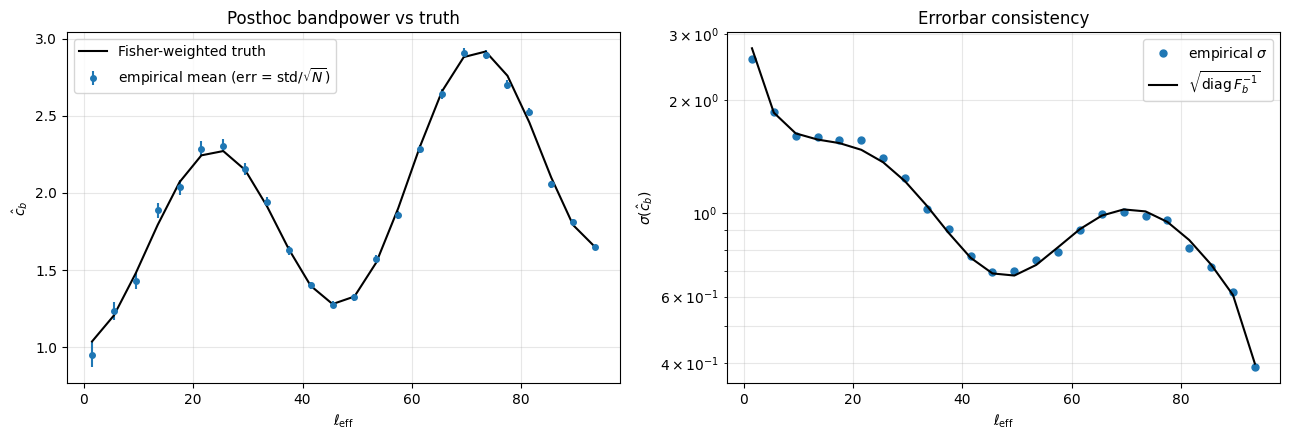

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

C_true_b1 = block_S.T @ C_aa[:n_ell]

ax = axes[0]
ax.errorbar(ell_eff, c_mean, yerr=sigma_emp/np.sqrt(n_sims),
            fmt='o', ms=4, label='empirical mean (err = std/$\\sqrt{N}$)')
ax.plot(ell_eff, C_true_b, 'k-', lw=1.5, label='Fisher-weighted truth')
ax.set_xlabel(r'$\ell_{\rm eff}$')
ax.set_ylabel(r'$\hat{c}_b$')
ax.set_title('Posthoc bandpower vs truth')
ax.legend()
ax.grid(alpha=0.3)

ax = axes[1]
ax.semilogy(ell_eff, sigma_emp, 'o', ms=5, label=r'empirical $\sigma$')
ax.semilogy(ell_eff, sigma_an,  'k-', lw=1.5, label=r'$\sqrt{\mathrm{diag}\,F_b^{-1}}$')
ax.set_xlabel(r'$\ell_{\rm eff}$')
ax.set_ylabel(r'$\sigma(\hat{c}_b)$')
ax.set_title('Errorbar consistency')
ax.legend()
ax.grid(alpha=0.3, which='both')

plt.tight_layout()
plt.show()

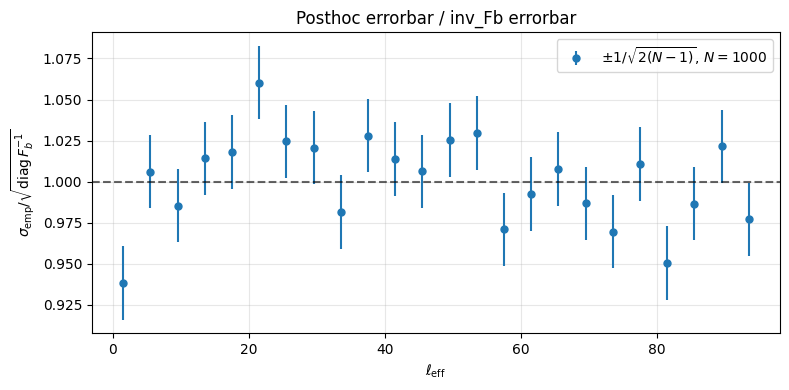

In [16]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.errorbar(ell_eff, ratio, yerr=ratio_err, fmt='o', ms=5,
            label=fr'$\pm 1/\sqrt{{2(N-1)}}$, $N={n_sims}$')
ax.axhline(1.0, color='k', ls='--', alpha=0.6)
ax.set_xlabel(r'$\ell_{\rm eff}$')
ax.set_ylabel(r'$\sigma_{\rm emp} / \sqrt{\mathrm{diag}\,F_b^{-1}}$')
ax.set_title('Posthoc errorbar / inv_Fb errorbar')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Full covariance matrix consistency

Beyond diagonals: the empirical covariance of $\hat{c}_b$ should match the full
matrix $F_b^{-1}$, including off-diagonal correlations between bins.

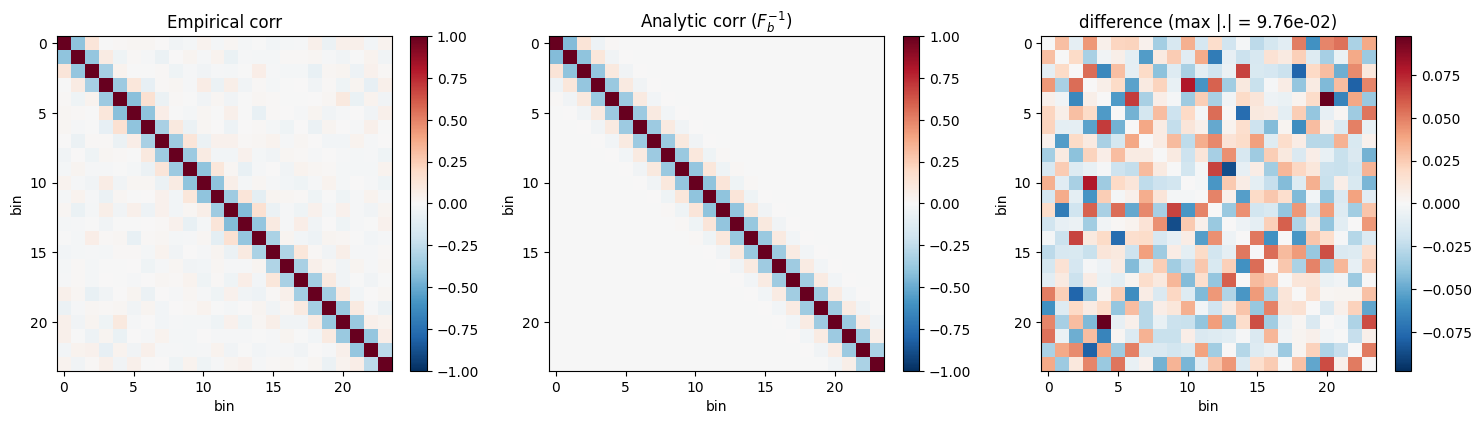

In [17]:
# Correlation matrices for visualization
def cov_to_corr(C):
    d = np.sqrt(np.diag(C))
    return C / np.outer(d, d)

corr_emp = cov_to_corr(c_cov_emp)
corr_an  = cov_to_corr(inv_Fb)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
vmax = max(np.abs(corr_emp).max(), np.abs(corr_an).max())

im = axes[0].imshow(corr_emp, vmin=-1, vmax=1, cmap='RdBu_r')
axes[0].set_title('Empirical corr')
plt.colorbar(im, ax=axes[0], fraction=0.046)

im = axes[1].imshow(corr_an, vmin=-1, vmax=1, cmap='RdBu_r')
axes[1].set_title(r'Analytic corr ($F_b^{-1}$)')
plt.colorbar(im, ax=axes[1], fraction=0.046)

diff = corr_emp - corr_an
vd = np.abs(diff).max()
im = axes[2].imshow(diff, vmin=-vd, vmax=vd, cmap='RdBu_r')
axes[2].set_title(f'difference (max |.| = {vd:.2e})')
plt.colorbar(im, ax=axes[2], fraction=0.046)

for a in axes:
    a.set_xlabel('bin')
    a.set_ylabel('bin')
plt.tight_layout()
plt.show()

In [16]:
# Whitened covariance: W = L^-1 C_emp L^-T  (should be ~ I)
L = np.linalg.cholesky(inv_Fb)
Linv = np.linalg.inv(L)
W = Linv @ c_cov_emp @ Linv.T

# Under the null (C_emp drawn from Wishart with true cov = inv_Fb),
# each eigenvalue of W scatters around 1 with std ~ sqrt(2/(n_sims-1)).
eig_std = np.sqrt(2.0 / (n_sims - 1))
eigs = np.linalg.eigvalsh(W)
z_eigs = (eigs - 1) / eig_std

print(f'Whitened eigenvalues (expect 1 +/- {eig_std:.3f}):')
print(eigs)
print(f'\nz-scores: {z_eigs}')
print(f'max |z| = {np.max(np.abs(z_eigs)):.2f}  (expect < ~3)')
print(f'mean(diag W) = {np.diag(W).mean():.4f}  (expect 1.0)')


### Bias check: $(\hat{c}_b - c^{\rm true}_b)$ in units of $\sigma/\sqrt{N_{\rm sims}}$

In [18]:
std_mean = sigma_emp / np.sqrt(n_sims)
residual = (c_mean - C_true_b) / std_mean
print('Residual (mean - truth) / sigma_mean:')
for b in range(n_bins):
    print(f'  bin {b:2d} (l_eff={ell_eff[b]:5.1f}): {residual[b]:+.2f} sigma')
rms = np.sqrt(np.mean(residual**2))
print(f'\nRMS = {rms:.2f} sigma  (expect ~1.0)')
print('PASSED' if rms < 3 else 'WARNING: possible residual bias')

Residual (mean - truth) / sigma_mean:
  bin  0 (l_eff=  1.5): -1.06 sigma
  bin  1 (l_eff=  5.5): +0.45 sigma
  bin  2 (l_eff=  9.5): -0.98 sigma
  bin  3 (l_eff= 13.5): +1.88 sigma
  bin  4 (l_eff= 17.5): -0.67 sigma
  bin  5 (l_eff= 21.5): +0.85 sigma
  bin  6 (l_eff= 25.5): +0.81 sigma
  bin  7 (l_eff= 29.5): +0.10 sigma
  bin  8 (l_eff= 33.5): +0.86 sigma
  bin  9 (l_eff= 37.5): -0.27 sigma
  bin 10 (l_eff= 41.5): +0.11 sigma
  bin 11 (l_eff= 45.5): -0.21 sigma
  bin 12 (l_eff= 49.5): -0.24 sigma
  bin 13 (l_eff= 53.5): +1.05 sigma
  bin 14 (l_eff= 57.5): -1.78 sigma
  bin 15 (l_eff= 61.5): -0.58 sigma
  bin 16 (l_eff= 65.5): -0.46 sigma
  bin 17 (l_eff= 69.5): +0.78 sigma
  bin 18 (l_eff= 73.5): -0.66 sigma
  bin 19 (l_eff= 77.5): -1.91 sigma
  bin 20 (l_eff= 81.5): +2.56 sigma
  bin 21 (l_eff= 85.5): -1.98 sigma
  bin 22 (l_eff= 89.5): +1.14 sigma
  bin 23 (l_eff= 93.5): -0.06 sigma

RMS = 1.12 sigma  (expect ~1.0)
PASSED


### Direct binned estimator

$\hat{c}_b^{\rm direct} = (F_b^{\rm direct})^{-1}\,\hat{y}_b^{\rm sub}$,
where $\hat{y}_b$ is computed from the eigendecomposed binned basis $V_b$.

In [19]:
c_hat_direct = ys_bin @ inv_Fb_direct.T
c_mean_direct = c_hat_direct.mean(axis=0)
c_cov_direct = np.cov(c_hat_direct, rowvar=False, ddof=1)

sigma_direct = np.sqrt(np.diag(c_cov_direct))
sigma_an_direct = np.sqrt(np.diag(inv_Fb_direct))


### Posthoc vs direct binned: consistency

Both estimators are algebraically identical
($(PFS)^{-1}P = (S^T F S)^{-1}S^T$ and $\hat{y}_b = S^T \hat{y}_\ell$),
so their means, errorbars, and the analytic $F_b^{-1}$ should all agree.

In [20]:
print(f'{"bin":>3} {"l_eff":>6} {"sig_posthoc":>12} {"sig_direct":>12} '
      f'{"sig_analytic":>12} {"post/an":>9} {"dir/an":>9} {"post/dir":>9}')
for b in range(n_bins):
    sp = sigma_emp[b]
    sd = sigma_direct[b]
    sa = sigma_an[b]
    print(f'{b:>3d} {ell_eff[b]:>6.1f} {sp:>12.4e} {sd:>12.4e} '
          f'{sa:>12.4e} {sp/sa:>9.4f} {sd/sa:>9.4f} {sp/sd:>9.4f}')

print(f'\nmean posthoc/analytic = {(sigma_emp/sigma_an).mean():.4f}')
print(f'mean direct/analytic  = {(sigma_direct/sigma_an_direct).mean():.4f}')
print(f'mean posthoc/direct   = {(sigma_emp/sigma_direct).mean():.4f}')


bin  l_eff  sig_posthoc   sig_direct sig_analytic   post/an    dir/an  post/dir
  0    1.5   2.5749e+00   2.5749e+00   2.7444e+00    0.9382    0.9382    1.0000
  1    5.5   1.8613e+00   1.8613e+00   1.8502e+00    1.0060    1.0060    1.0000
  2    9.5   1.6060e+00   1.6060e+00   1.6298e+00    0.9854    0.9854    1.0000
  3   13.5   1.5916e+00   1.5916e+00   1.5695e+00    1.0141    1.0141    1.0000
  4   17.5   1.5632e+00   1.5632e+00   1.5356e+00    1.0180    1.0180    1.0000
  5   21.5   1.5627e+00   1.5627e+00   1.4739e+00    1.0602    1.0602    1.0000
  6   25.5   1.3990e+00   1.3990e+00   1.3656e+00    1.0245    1.0245    1.0000
  7   29.5   1.2409e+00   1.2409e+00   1.2158e+00    1.0206    1.0206    1.0000
  8   33.5   1.0268e+00   1.0268e+00   1.0461e+00    0.9816    0.9816    1.0000
  9   37.5   9.1004e-01   9.1004e-01   8.8529e-01    1.0280    1.0280    1.0000
 10   41.5   7.7145e-01   7.7145e-01   7.6093e-01    1.0138    1.0138    1.0000
 11   45.5   6.9562e-01   6.9562e-01   6

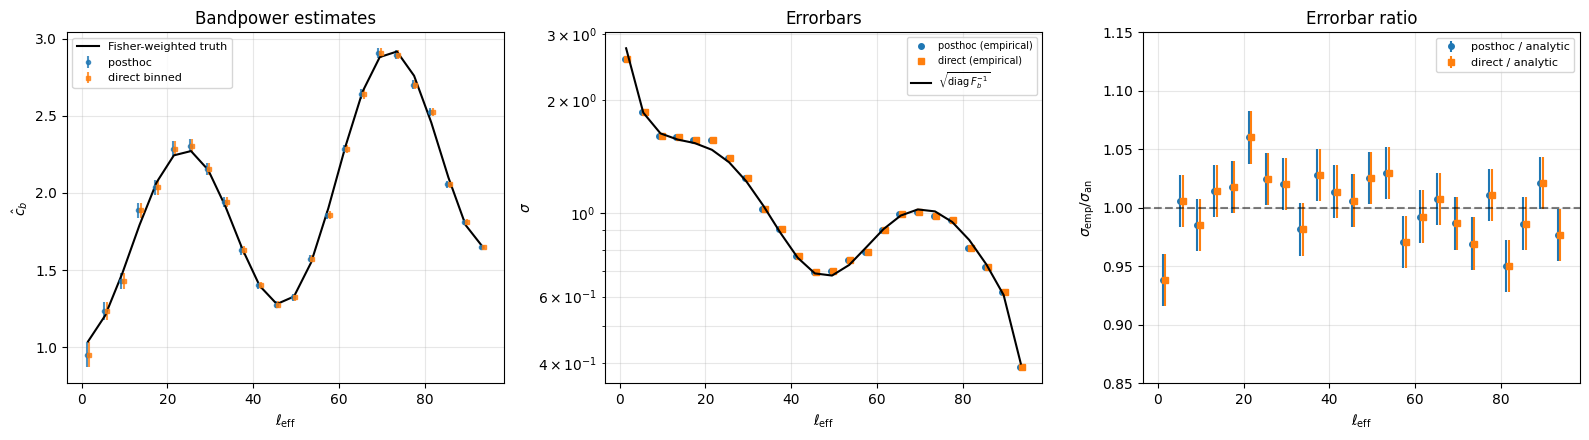

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
dx = 0.3

ax = axes[0]
ax.errorbar(ell_eff - dx, c_mean, yerr=sigma_emp/np.sqrt(n_sims),
            fmt='o', ms=3, label='posthoc', alpha=0.8)
ax.errorbar(ell_eff + dx, c_mean_direct, yerr=sigma_direct/np.sqrt(n_sims),
            fmt='s', ms=3, label='direct binned', alpha=0.8)
ax.plot(ell_eff, C_true_b, 'k-', lw=1.5, label='Fisher-weighted truth')
ax.set_xlabel(r'$\ell_{\rm eff}$')
ax.set_ylabel(r'$\hat{c}_b$')
ax.set_title('Bandpower estimates')
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

ax = axes[1]
ax.semilogy(ell_eff - dx, sigma_emp, 'o', ms=4, label='posthoc (empirical)')
ax.semilogy(ell_eff + dx, sigma_direct, 's', ms=4, label='direct (empirical)')
ax.semilogy(ell_eff, sigma_an, 'k-', lw=1.5, label=r'$\sqrt{\mathrm{diag}\,F_b^{-1}}$')
ax.set_xlabel(r'$\ell_{\rm eff}$')
ax.set_ylabel(r'$\sigma$')
ax.set_title('Errorbars')
ax.legend(fontsize=7)
ax.grid(alpha=0.3, which='both')

ax = axes[2]
ax.errorbar(ell_eff - dx, sigma_emp/sigma_an, yerr=ratio_err, fmt='o', ms=4,
            label='posthoc / analytic')
ax.errorbar(ell_eff + dx, sigma_direct/sigma_an_direct, yerr=ratio_err, fmt='s', ms=4,
            label='direct / analytic')
ax.axhline(1.0, color='k', ls='--', alpha=0.5)
ax.set_xlabel(r'$\ell_{\rm eff}$')
ax.set_ylabel(r'$\sigma_{\rm emp}/\sigma_{\rm an}$')
ax.set_title('Errorbar ratio')
ax.legend(fontsize=8)
ax.grid(alpha=0.3)
ax.set_ylim(0.85, 1.15)

plt.tight_layout()
plt.show()


In [22]:
# Posthoc / direct errorbar ratio — should be identically 1
ratio_pd = sigma_emp / sigma_direct
print('Posthoc / direct errorbar ratio (should be exactly 1.0):')
print(ratio_pd)

Posthoc / direct errorbar ratio (should be exactly 1.0):
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
